# Exploratory Data Analysis

Performing initial data analysis to observe potential patterns in the dataset before building a model. 

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_features
from src.preprocessing import clean_data

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [27]:
raw = load_features()
df = clean_data(raw)
df.shape

Loaded 101,766 rows, 54 columns.
Unique patients: 71,518

Columns with missing values:
race      2367
gender       3

Readmitted-within-30-days rate: 11.16%

  Dropped 2,423 rows with death/hospice discharge disposition.
  Dropped 3 rows with missing/invalid gender.
  Filled 2,320 missing race values with 'Unknown'.

Raw data: 101,766 encounters; Cleaned data: 99,340 encounters (2,426 dropped total).


(99340, 54)

In [ ]:
print("Dtype breakdown:")
print(df.dtypes.value_counts())

# Quick check to ensure data cleaning worked as expected; Should print "None"
print("\nRemaining missing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None")
print(df.select_dtypes(include='int64'))
# 21 int64 (numeric) features with 9 features that are non-binary and non-identifiers

Dtype breakdown:
str      33
int64    21
Name: count, dtype: int64

Remaining missing values:
None
        encounter_id  patient_nbr  age_numeric  time_in_hospital  \
0              12522     48330783           85                13   
1              15738     63555939           95                12   
2              16680     42519267           45                 1   
3              28236     89869032           45                 9   
4              35754     82637451           55                 3   
...              ...          ...          ...               ...   
101761     443847548    100162476           75                 3   
101762     443847782     74694222           85                 5   
101763     443854148     41088789           75                 1   
101764     443857166     31693671           85                10   
101765     443867222    175429310           75                 6   

        num_lab_procedures  num_procedures  num_medications  \
0                    

# Histogram of Numeric Features

Histogram plots were created to observe the distribution of values for various numerical features. This was done in two figures. The first figure evaluated 4 features that occurred within the encounter i.e. time in the hospital, number of lab procedures, number of procedures, number of medications. The second figure evaluated 3 features that addressed previous utilization of healthcare services in the past year i.e. number of inpatient visits, number of outpatient visits, and number of emergency visits. 

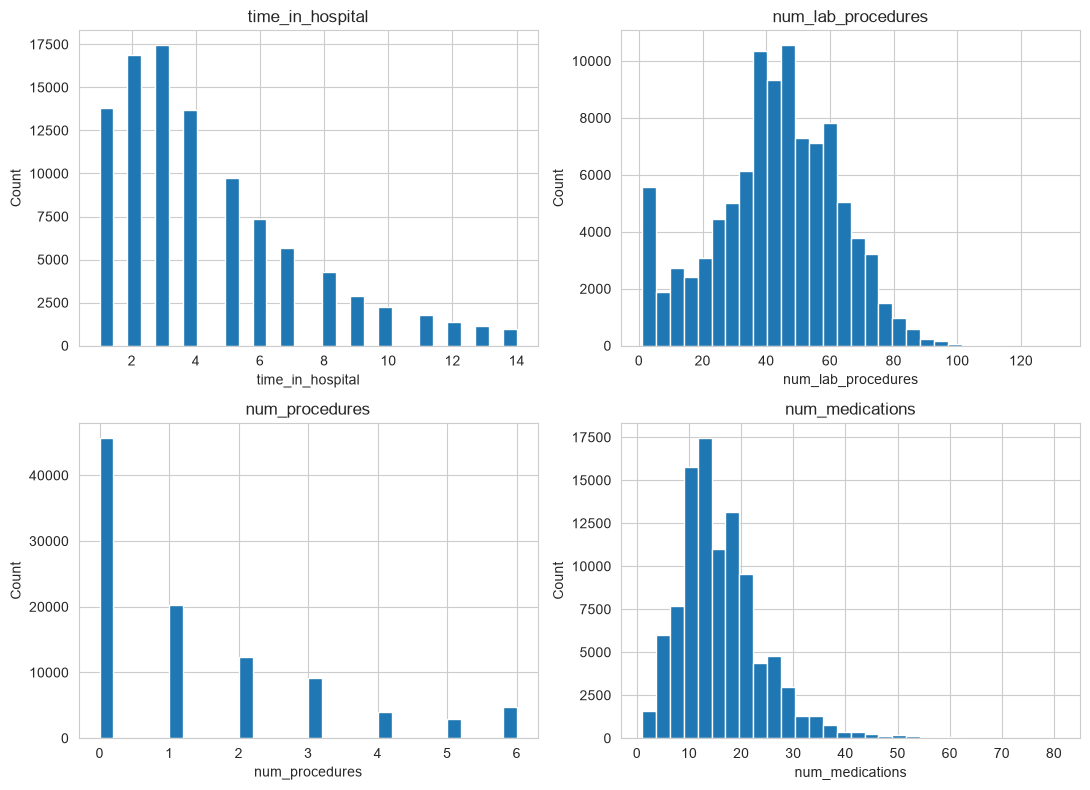

       time_in_hospital  num_lab_procedures  num_procedures  num_medications
count      99340.000000        99340.000000    99340.000000     99340.000000
mean           4.379364           42.907198        1.334196        15.979052
std            2.968393           19.609887        1.702770         8.094931
min            1.000000            1.000000        0.000000         1.000000
25%            2.000000           31.000000        0.000000        10.000000
50%            4.000000           44.000000        1.000000        15.000000
75%            6.000000           57.000000        2.000000        20.000000
max           14.000000          132.000000        6.000000        81.000000


In [6]:
numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(df[numeric_cols].describe())

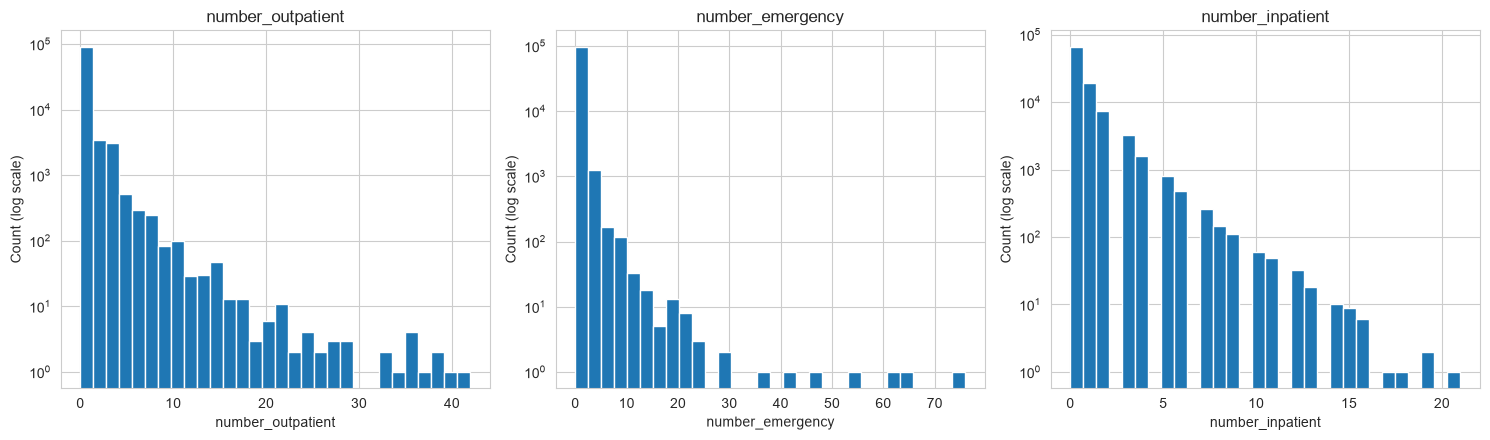

       number_outpatient  number_emergency  number_inpatient
count       99340.000000      99340.000000      99340.000000
mean            0.369257          0.198450          0.630954
std             1.265160          0.937747          1.260443
min             0.000000          0.000000          0.000000
25%             0.000000          0.000000          0.000000
50%             0.000000          0.000000          0.000000
75%             0.000000          0.000000          1.000000
max            42.000000         76.000000         21.000000

Percent of encounters with zero prior visits:
number_outpatient    83.542380
number_emergency     88.832293
number_inpatient     66.682102
dtype: float64


In [7]:
# numeric columns related to prior utilization of healthcare services
prior_util_cols = ["number_outpatient", "number_emergency", "number_inpatient"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# since these columns are highly skewed, use log scale for y-axis
for i, col in enumerate(prior_util_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count (log scale)")
    axes[i].set_yscale("log")

plt.tight_layout()
plt.show()

print(df[prior_util_cols].describe())
print("\nPercent of encounters with zero prior visits:")
print((df[prior_util_cols] == 0).mean() * 100)

# SQL Data Analysis 

The following cells present data analysis first performed using SQL, as SQL was naturally more suited in conducting this type of analysis. The standalone SQL queries are stored in sql/data_analysis.sql. 

### The Questions Being Asked: 

All queries were answering how specific features related to the readmission rate within 30 days. Each query will group by the unique values of the feature being analyzed. 

Here are the features being analyzed: 
1. Number of Inpatient visits within the last year
2. Primary Diagnosis Category
3. Discharge Disposition
4. HbA1c Results 

Discussion of the results will be at the end of this section. 

In [29]:
import sqlite3
from src.data_loader import default_db_path

# Number of Inpatient visits query
# separated into 4 groups: 0, 1, 2, 3, 3+ 
query = """
SELECT
    CASE
        WHEN number_inpatient = 0 THEN '0'
        WHEN number_inpatient = 1 THEN '1'
        WHEN number_inpatient = 2 THEN '2'
        ELSE '3+'
    END AS prior_inpatient_visits,
    COUNT(*) AS encounters,
    ROUND(AVG(readmitted_30) * 100, 2) AS readmit_rate_pct
FROM ml_features
WHERE discharge_disposition NOT IN (
    'Expired', 
    'Hospice / home', 
    'Hospice / medical facility',
    'Expired at home. Medicaid only, hospice.',
    'Expired in a medical facility. Medicaid only, hospice.',
    'Expired, place unknown. Medicaid only, hospice.' 
) AND gender IS NOT NULL AND gender != 'Unknown/Invalid'
GROUP BY prior_inpatient_visits
ORDER BY prior_inpatient_visits;
"""

conn = sqlite3.connect(default_db_path)
prior_util_result = pd.read_sql_query(query, conn)
conn.close()

prior_util_result

,prior_inpatient_visits,encounters,readmit_rate_pct
0,0,66242,8.59
1,1,18984,13.25
2,2,7300,17.93
3,3+,6814,26.40


In [30]:
# Primary Diagnosis Category
query = """
SELECT
    primary_diagnosis_category,
    COUNT(*) AS encounters,
    ROUND(AVG(readmitted_30) * 100, 2) AS readmit_rate_pct
FROM ml_features
WHERE discharge_disposition NOT IN (
    'Expired', 
    'Hospice / home', 
    'Hospice / medical facility',
    'Expired at home. Medicaid only, hospice.',
    'Expired in a medical facility. Medicaid only, hospice.',
    'Expired, place unknown. Medicaid only, hospice.' 
) AND gender IS NOT NULL AND gender != 'Unknown/Invalid'
GROUP BY primary_diagnosis_category
ORDER BY readmit_rate_pct DESC;
"""

conn = sqlite3.connect(default_db_path)
diagnosis_result = pd.read_sql_query(query, conn)
conn.close()

diagnosis_result

,primary_diagnosis_category,encounters,readmit_rate_pct
0,none,20,25.00
1,diabetes,8661,13.10
2,injury,6851,12.41
3,circulatory,29680,11.69
4,other,17793,11.68
5,genitourinary,5002,11.04
6,neoplasms,3131,10.89
7,digestive,9333,10.82
8,respiratory,13934,10.06
9,musculoskeletal,4935,9.54


In [31]:
# Discharge Disposition
# Drops catecorgies with <100 encounters
query = """
SELECT
    discharge_disposition,
    COUNT(*) AS encounters,
    ROUND(AVG(readmitted_30) * 100, 2) AS readmit_rate_pct
FROM ml_features
WHERE discharge_disposition NOT IN (
    'Expired', 
    'Hospice / home', 
    'Hospice / medical facility',
    'Expired at home. Medicaid only, hospice.',
    'Expired in a medical facility. Medicaid only, hospice.',
    'Expired, place unknown. Medicaid only, hospice.' 
) AND gender IS NOT NULL AND gender != 'Unknown/Invalid'
GROUP BY discharge_disposition
HAVING COUNT(*) > 100
ORDER BY readmit_rate_pct DESC;
"""

conn = sqlite3.connect(default_db_path)
disposition_result = pd.read_sql_query(query, conn)
conn.close()

disposition_result

,discharge_disposition,encounters,readmit_rate_pct
0,Discharged/transferred/referred to a psychiatr...,139,36.69
1,Discharged/transferred to another rehab fac in...,1992,27.71
2,Discharged/transferred to another type of inpa...,1184,20.86
3,Discharged/transferred to another short term h...,2128,16.07
4,Discharged/transferred to SNF,13954,14.66
5,Left AMA,623,14.45
6,Discharged/transferred to home under care of H...,108,13.89
7,Discharged/transferred to ICF,815,12.76
8,Discharged/transferred to home with home healt...,12902,12.70
9,NULL,3691,12.44


In [32]:
# HbA1c Result
query = """
SELECT
    A1Cresult,
    COUNT(*) AS encounters,
    ROUND(AVG(readmitted_30) * 100, 2) AS readmit_rate_pct
FROM ml_features
WHERE discharge_disposition NOT IN (
    'Expired', 
    'Hospice / home', 
    'Hospice / medical facility',
    'Expired at home. Medicaid only, hospice.',
    'Expired in a medical facility. Medicaid only, hospice.',
    'Expired, place unknown. Medicaid only, hospice.' 
) AND gender IS NOT NULL AND gender != 'Unknown/Invalid'
GROUP BY A1Cresult
ORDER BY readmit_rate_pct DESC;
"""

conn = sqlite3.connect(default_db_path)
a1c_result = pd.read_sql_query(query, conn)
conn.close()

a1c_result

,A1Cresult,encounters,readmit_rate_pct
0,None,82506,11.69
1,>7,3775,10.15
2,>8,8137,9.94
3,Norm,4922,9.77


## Discussion of SQL Query Results

**Inpatient visits are a clear indicator of readmission within 30 days** 

The increasing number of inpatient visits show a clear trend of increasing likelihood of readmission. With no prior inpatient visits in the past year, encounters had an 8.59% chance of readmission, which is below the dataset likelihood of 11.16%. Those encounters with over 3 inpatient visits in the past year, had a striking 26.4% chance of readmission. 

**Primary Diagnostics yields Expected Results** 

Encounters that had no primary diagnosis yielded an early readmission rate of 25%, but the small sample size of only 20 encounters makes it statistically unreliable to draw any conclusions. The next three diagnoses: diabetes, injury, and circulatory have the highest readmission rate. These diagnoses make clinical sense. Diabetes is the main population/demographic of the dataset. Injury may have more complex situations that may involve readmission to fully resolve. Circulatory conditions are heavily related to diabetes. 

**Transfer to Another Form of Care has Elevated Readmission Rates**

A clear pattern can be observed. The top 5 highest readmission rates are all related to dischage/transfer of the patient to some other form of care. With the highest readmission rate being 36.69% (though the sample size is just over 100 the results should be taken with a grain of salt). The discharge variants below it (top 2-4) had a larger sample size (>1000) with readmission rates ranging from ~16-27%. 

**HbA1C Results agree with the Source Paper** 

Strack et. al. (2014) states the importance of taking the HbA1c test during these encounters. The query found that not taking the HbA1c test had an increased chance of readmission (11.69%) compared to patients that did take the test (9.77%-10.15%). 

# Correlation Matrix

Goal: check if any numeric features are redundant (by seeing which ones are highly correlated) and which features are most correlated with early readmission. 

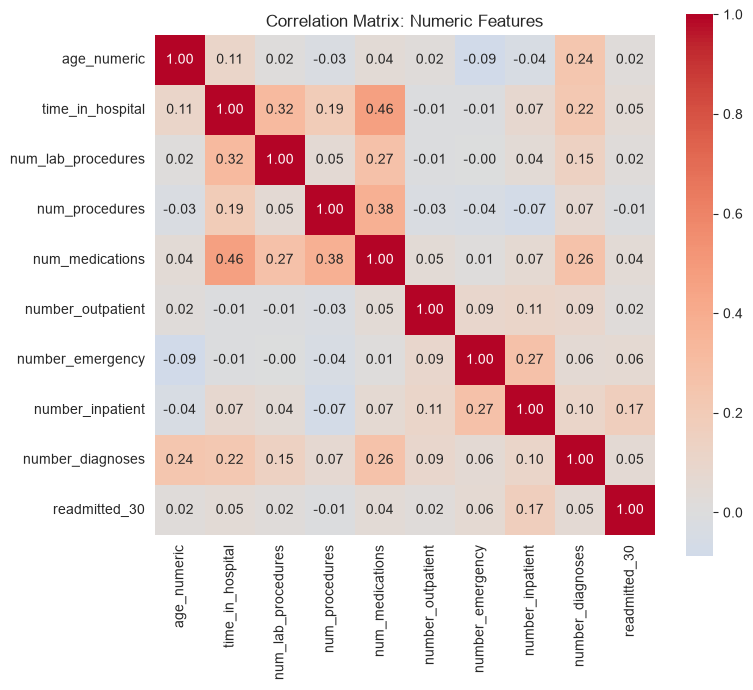

In [35]:
numeric_features = [
    "age_numeric", "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses", "readmitted_30"
]

corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax)
ax.set_title("Correlation Matrix: Numeric Features")
plt.tight_layout()
plt.show()

### Conclusions

The correlation matrix shows no near-duplicate features (nothing above ~0.5), though time_in_hospital, num_procedures, and num_medications form a mild cluster (0.32-0.46), consistent with all three reflecting encounter intensity. Correlations with the target are uniformly weak, with the max of 0.17 for number_inpatient, which agrees with the SQL results that inpatient visits was a strong indicator of early readmission. 